# Notebook Overview
This notebook trains a CatBoost regression model to predict house prices.

It loads cleaned data, prepares features and categorical columns, trains using GPU, evaluates model performance, saves the model, and visualizes predicted vs actual prices.

### Imports & Constants
Imports necessary libraries (pandas, CatBoost, sklearn metrics/split, time, matplotlib, seaborn) and sets key constants:
- `RAW_DATA_FILE` — source of cleaned data
- `MODEL_NAME` — filename to save the trained CatBoost model

In [15]:
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import time
import matplotlib.pyplot as plt
import seaborn as sns
RAW_DATA_FILE = 'cleaned_usa_housing.zip'
MODEL_NAME = 'house_price_model.cbm'

### Load Data
Load the cleaned dataset from `RAW_DATA_FILE` into a pandas DataFrame and print the number of rows loaded for confirmation.

In [9]:
print(f"Loading {RAW_DATA_FILE}...")
df = pd.read_csv(RAW_DATA_FILE)

print(f"Row Count: {len(df):,}")

Loading cleaned_usa_housing.zip...
Row Count: 1,354,993


### Feature Preparation & Train/Test Split
- Separate target (`y = price`) and features (`X`).
- Convert `zip_code` to string and identify categorical features for CatBoost.
- Split the data into training (80%) and test (20%) sets using a fixed random seed for reproducibility.

In [10]:
y = df['price']
X = df.drop(columns=['price'])

print(f"\nFeatures used for training: {list(X.columns)}")

# Identify Categorical Columns automatically for CatBoost (City, State, Zip)
X['zip_code'] = X['zip_code'].astype(str)
categorical_features = list(X.select_dtypes(include=['object', 'category']).columns)
print(f"Categorical Features: {categorical_features}")

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Features used for training: ['bed', 'bath', 'city', 'state', 'zip_code', 'house_size', 'lot_size_sqft']
Categorical Features: ['city', 'state', 'zip_code']


### Model Initialization
Initialize a CatBoostRegressor with chosen hyperparameters (iterations, learning_rate, depth, loss and eval metrics) configured to run on GPU (`task_type='GPU'`) and set `verbose` to monitor progress.

In [11]:
print("\nInitializing CatBoost on RTX 3070...")

model = CatBoostRegressor(
    iterations=2000,        # Cycles of learning
    learning_rate=0.1,      # How fast it learns
    depth=8,                # Depth of decision trees
    loss_function='RMSE',   # Optimize for Root Mean Squared Error
    eval_metric='MAE',      # Report Mean Absolute Error ($)
    task_type="GPU",        # <--- ENABLE GPU
    devices='0',            # Use first GPU
    verbose=200             # Print status every 200 steps
)


Initializing CatBoost on RTX 3070...


### Training the Model
Start a timer, then train the CatBoost model on `X_train`/`y_train` using the `eval_set` for early stopping. Prints total training time when finished.

In [12]:
start_time = time.time()
model.fit(
    X_train, y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50 # Stop if accuracy doesn't improve for 50 rounds
)
end_time = time.time()

print(f"\nTraining Complete! Time taken: {end_time - start_time:.2f} seconds")

Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 323747.5764036	test: 323579.8132982	best: 323579.8132982 (0)	total: 71.3ms	remaining: 2m 22s
200:	learn: 152701.1459621	test: 150392.7370359	best: 150392.7370359 (200)	total: 11.4s	remaining: 1m 42s
400:	learn: 146315.9756235	test: 145231.1987572	best: 145231.1987572 (400)	total: 22.7s	remaining: 1m 30s
600:	learn: 142425.6458394	test: 142402.4544445	best: 142402.4544445 (600)	total: 33.9s	remaining: 1m 18s
800:	learn: 138941.3966498	test: 139772.7371688	best: 139772.7371688 (800)	total: 45s	remaining: 1m 7s
1000:	learn: 136494.8317279	test: 138129.2828977	best: 138129.2828977 (1000)	total: 56.3s	remaining: 56.2s
1200:	learn: 134577.5757135	test: 137001.8056155	best: 137001.8056155 (1200)	total: 1m 7s	remaining: 44.8s
1400:	learn: 132507.9809076	test: 135594.4087764	best: 135594.4087764 (1400)	total: 1m 18s	remaining: 33.7s
1600:	learn: 130750.8627539	test: 134503.9467747	best: 134503.9467747 (1598)	total: 1m 30s	remaining: 22.5s
1800:	learn: 129208.2945699	test: 133652.83715

### Evaluation & Save
- Predict on the test set, compute Mean Absolute Error (MAE) and R².
- Print performance summary and a simple verdict.
- Save the trained model to `MODEL_NAME` for later use.

In [13]:
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n------------------------------------------------")
print("FINAL MODEL PERFORMANCE")
print("------------------------------------------------")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R2 Score (Accuracy):       {r2:.4f}")
print("------------------------------------------------")

if r2 > 0.70:
    print("Verdict: The model is GOOD. Ready for use.")
else:
    print("Verdict: The model is WEAK. Consider more data cleaning.")

# Save
model.save_model(MODEL_NAME)
print(f"\nModel saved to: {MODEL_NAME}")


------------------------------------------------
FINAL MODEL PERFORMANCE
------------------------------------------------
Mean Absolute Error (MAE): $132,824.18
R2 Score (Accuracy):       0.7657
------------------------------------------------
Verdict: The model is GOOD. Ready for use.

Model saved to: house_price_model.cbm


### Visualization — Predicted vs Actual
Create a scatter plot of predicted vs actual prices (log-log scale) and draw a dashed red ‘Perfect Prediction’ line to visually assess model accuracy across price ranges.

Displaying plot...


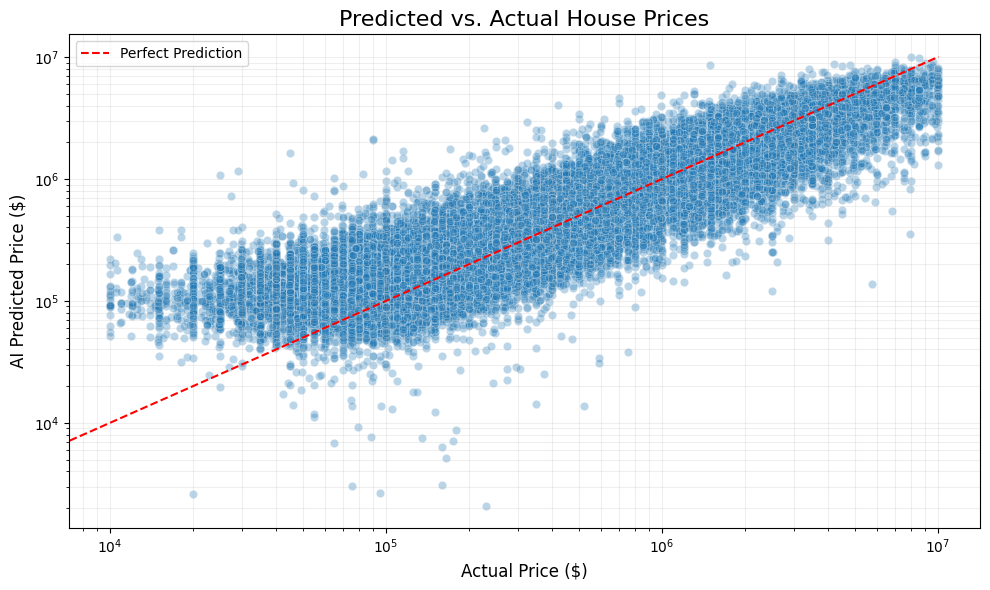

In [16]:
plt.figure(figsize=(10, 6))

# Scatter plot of points
sns.scatterplot(x=y_test, y=predictions, alpha=0.3)

# Draw a red "Perfect Prediction" line
# Points on this line are 100% accurate.
m = max(y_test.max(), predictions.max())
plt.plot([0, m], [0, m], color='red', linestyle='--', label='Perfect Prediction')

# Labels
plt.title('Predicted vs. Actual House Prices', fontsize=16)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('AI Predicted Price ($)', fontsize=12)
plt.legend()

# Optional: Log Scale (because $10M houses squash the chart)
plt.xscale('log')
plt.yscale('log')

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

print("Displaying plot...")
plt.show()